# Alpha coefficients - Wind scaling power law

**Last updated:** 2026-08-17

[![logo](https://climate.copernicus.eu/sites/default/files/custom-uploads/branding/LogoLine_horizon_C3S.png)](https://climate.copernicus.eu)

In the following Notebook, we will have a look at how to compute wind speed at a desired height (e.g. 84 meters and 100 meters) for climate projection models, starting from wind speed at a reference height (e.g. 10 meters) making use of wind speed scaling coeffiecient (alpha) through a power law. The alpha coefficients file contains data for each latitude-longitude grid point and for each month and hour of the day. It has been produced starting from ERA5 data of wind speed at 10 meters and at 100 meters, both bias adjusted with the delta method using data coming from the Global Wind Atlas version 2 (GWA).

For illustration purposes, this notebook uses a short temporal subsample of ws10 from the C3S Energy Lot1 dataset. This approach is intended to demonstrate the workflow and methodology.

It is important to emphasize that for rigorous climate impact studies, the use of such limited data is not sufficient. Reliable analyses should be based on longer time series (typically at least 30 years).  
We will consider two months of one year (2030) of data from a CMIP6 climate model (ECE3) and a specific climate change scenario (SSP2-4.5). The analysis could be extended to consider more years and also others climate models and/or scenarios.

After reading the needed data from the CDS, we will apply the wind speed scaling power law to compute wind speed data at 84 meters and 100 meters, then we will visualize it by generating figures that will help us understanding the data generated, namely a map of mean wind speed for may at 4:00 PM and a map of mean wind speed for december at 9:00 PM.
All the code will be in Python.

## Learning objectives 🎯

Throughout this notebook, you will:
* understand the Wind Shear Power Law
* learn how to read C3S Energy Lot1 NetCDF files of wind speed and alpha scaling coefficients
* how to define a function in order to apply the power_law to compute wind speed at any desired height
* how to plot a map of average wind speed at a specified month and hour of the day.

## Target Audience 🎯

**Anyone** interested in learning what scaling cofficients are and how to use them to compute wind speed at a desired height given a dataset of wind speed at a reference height, making use of wind speed data from Lot1 climate projection models.

## The physical meaning of the Wind Speed Power Law

The wind speed power law is an empirical relationship used to estimate how wind speed changes with height above ground level within the atmospheric boundary layer (ABL). It reflects how friction and turbulence near the surface slow down the wind and how this effect decreases with height.
The physical idea is that near the ground, roughness elements (such as trees, buildings, terrain) create friction, which dissipates momentum. As you climb, the effects of friction weaken, so the wind accelerates. The rate of this increase (wind shear) depends on the roughness of the surface and the stability of the atmosphere (which varies depending on the time of day and season).

### Mathematical formula

The power law expresses the wind speed $w(z)$ at height $h$ as:
$$w(z)=w_{ref}\left(\frac{h(z)}{h_{ref}}\right)^{\alpha}$$
where:
* $w_{ref}$ : known wind speed at reference height $h_{ref}$, the typical refernce height is 10 meters
* $\alpha$ : wind shear exponent (dimensionless)

## Prepare your environment

### Import required packages

We start by importing some useful libraries. These include: [os](https://docs.python.org/3/library/os.html) and [glob](https://docs.python.org/3/library/glob.html), which provide ways to interact with the operating system and are used here to manipulate paths and find files; [zipfile](https://docs.python.org/3/library/zipfile.html), used to extract the downloaded archives; [cdsapi](https://cds.climate.copernicus.eu/how-to-api), the client used to download data from the Climate Data Store; [matplotlib](https://matplotlib.org/), a standard library for creating visualizations in Python; [xarray](https://docs.xarray.dev/en/stable/index.html), a library to work with multidimensional arrays in NetCDF format.

In [ ]:
# importing libraries
import glob
import os
import zipfile

import cdsapi
import matplotlib.pyplot as plt
import xarray as xr

## Download the data

Both the alpha coefficients and the wind speed at 10 meters come from the [Pan-European Climate Database (PECD)](https://cds.climate.copernicus.eu/datasets/sis-energy-pecd) available on the Climate Data Store (CDS). Downloading requires a free CDS account and the `cdsapi` package configured with your credentials (see the [CDS API how-to](https://cds.climate.copernicus.eu/how-to-api)).

We download the PECDv4.1 alpha coefficients ancillary file together with a short subsample of the wind speed at 10 meters data: the months of May and December of 2030, from the EC-Earth3 (ECE3) climate model under the SSP2-4.5 emission scenario (the only scenario distributed for PECDv4.1 projections on the CDS). The files are downloaded only if they are not already present in the local `data` folder.

In [ ]:
# CDS dataset providing both the alpha coefficients and the wind speed data
dataset = "sis-energy-pecd"

# local data folders
alpha_dir = "./data/alph"
ws10_dir = "./data/ws10"


def download_and_extract(request, out_dir):
    """Download a CDS request and place the resulting NetCDF file(s) in out_dir."""
    os.makedirs(out_dir, exist_ok=True)
    client = cdsapi.Client()
    target = client.retrieve(dataset, request).download()
    if zipfile.is_zipfile(target):
        with zipfile.ZipFile(target) as zip_ref:
            zip_ref.extractall(out_dir)
        os.remove(target)
    else:
        os.replace(target, os.path.join(out_dir, os.path.basename(target)))


# alpha power law coefficients (PECDv4.1 ancillary file)
if not glob.glob(f"{alpha_dir}/*.nc"):
    download_and_extract(
        {
            "pecd_version": "deprecated",
            "variable": ["power_law_coefficient"],
        },
        alpha_dir,
    )

# wind speed at 10 meters: May and December 2030, EC-Earth3 model, SSP2-4.5 scenario
if not glob.glob(f"{ws10_dir}/*.nc"):
    download_and_extract(
        {
            "pecd_version": "deprecated",
            "temporal_period": ["future_projections"],
            "origin": ["ec_earth3"],
            "emission_scenario": ["ssp2_4_5"],
            "variable": ["10m_wind_speed"],
            "spatial_resolution": ["0_25_degree"],
            "year": ["2030"],
            "month": ["05", "12"],
        },
        ws10_dir,
    )

## Load the data

Now we load alpha coefficients file into a Xarray datarray. For each grid point, it contains data for each month and hour of the day

In [ ]:
# find the downloaded alpha coefficients file
alpha_file = min(glob.glob(f"{alpha_dir}/*.nc"))
# load into alpha datarray
alpha = xr.open_dataset(alpha_file).alpha
# show result datarray
alpha

We can notice that longitude values of alpha spans [0,359.75]. We want to convert it to [-180, 180]; to do this, we will define a function to handle the calculation:

In [4]:
# function to convert longitude values from 0, 360 to -180,180
def shift_longitude(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
    return ds.sortby("longitude")


# convert longitude
alpha = shift_longitude(alpha)
alpha

<xarray.DataArray 'alpha' (time: 288, latitude: 721, longitude: 1440)> Size: 1GB
[299013120 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 2kB 2011-01-01 ... 2011-12-01T23:00:00
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Attributes:
    units:          -
    long_name:      alpha power law coefficient
    short_name:     alpha
    standard_name:  alpha_power_law_coefficient

### Relation to surface roughness

Surface roughness determines the amount of kinetic energy that is subtracted from the flow:
smooth surfaces (e.g., open water, ice, short grass) have low friction, which translates into low alpha values, while
rough surfaces (e.g., forests, cities) have high friction, which means high alpha values.
This is because rougher surfaces create more turbulence, extending the layer of slowed air higher into the atmosphere.

Let's plot the scaling coeffients for a given month and hour

Data source: [Pan-European Climate Database (PECD), C3S Climate Data Store](https://cds.climate.copernicus.eu/datasets/sis-energy-pecd)

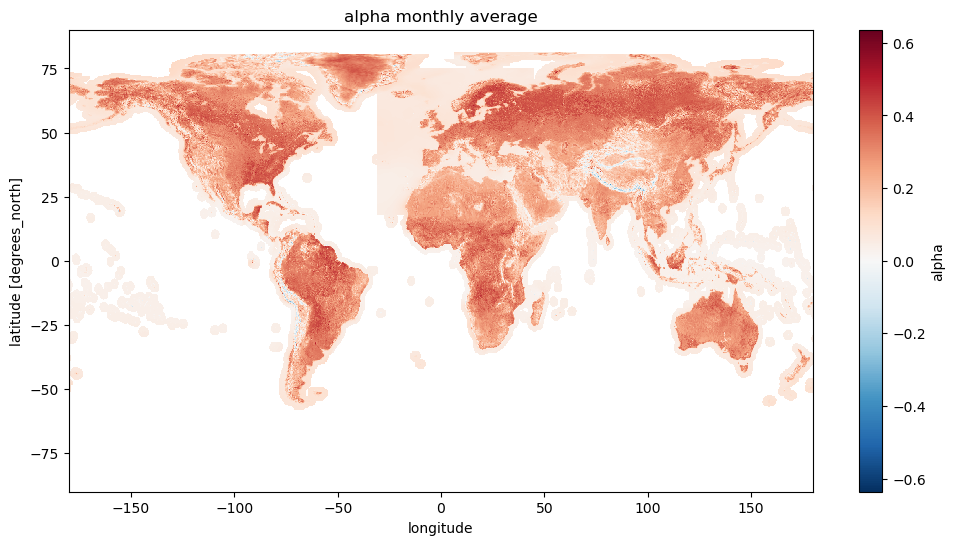

In [5]:
plt.figure(figsize=(12, 6))
alpha.mean(dim="time").plot()
title = plt.title("alpha monthly average")

### Relation to Atmospheric Stability, Daily & Seasonal Cycles

The exponent $\alpha$ also varies with atmospheric stability, which changes over day and night and across seasons.

Let's select one location over land and one over sea. We will then we plot the seasonal cycle by taking the average over time after applying the groupby method over month.
The exponent should change across seasons:
* In winter, long nights and stable stratification → higher $\alpha$
* In summer, stronger solar heating → more convective mixing → lower $\alpha$

It varies strongly also between land and sea because of the surface roughness:
* Over the sea: water surfaces are very smooth → low surface roughness → wind changes slowly with height → lower $\alpha$
* over land: Llnd has higher and more variable roughness (vegetation, buildings, terrain) → higher $\alpha$.

Data source: [Pan-European Climate Database (PECD), C3S Climate Data Store](https://cds.climate.copernicus.eu/datasets/sis-energy-pecd)

In [6]:
land_lat, land_lon = 53, 11  # near Hamburg
sea_lat, sea_lon = 55, 6  # North Sea

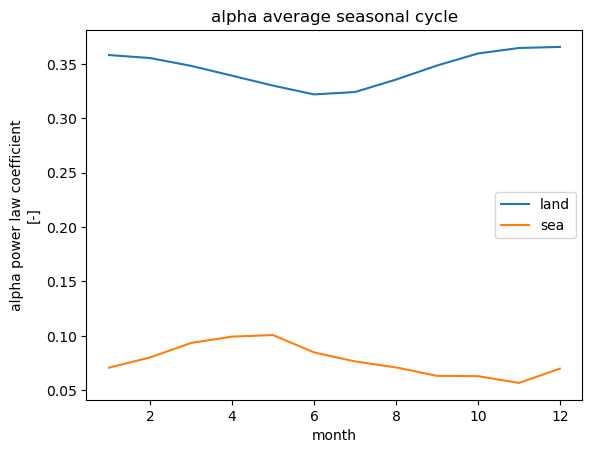

In [7]:
alpha.sel(latitude=land_lat, longitude=land_lon, method="nearest").groupby(
    "time.month"
).mean().plot(label="land")
alpha.sel(latitude=sea_lat, longitude=sea_lon, method="nearest").groupby(
    "time.month"
).mean().plot(label="sea")
plt.title("alpha average seasonal cycle")
plt.legend()

One can see how the average (over hours of the day) scaling coefficient varies as a function of the month for the given location. Indeed values are lower in the summer and higher in the winter season for the land location; for the sea location, there are some months of lag in the seasonal cycle. 

Next we will plot the average over all months for each hour of the day. The exponent should vary in the following way:
* Daytime (unstable)
Surface heating causes convective turbulence, enhancing mixing.
The vertical temperature gradient is small (or negative), so momentum is well mixed.
Wind profile is more uniform → small $\alpha$ (≈ 0.1)
* Nighttime (stable)
The ground cools, suppressing turbulence.
Wind speed near the surface drops sharply, but remains strong aloft.
Wind shear is large → large $\alpha$ (≈ 0.4)

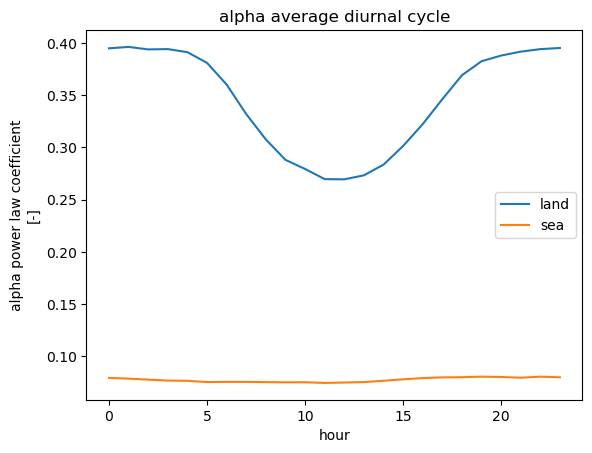

In [8]:
alpha.sel(latitude=land_lat, longitude=land_lon, method="nearest").groupby(
    "time.hour"
).mean().plot(label="land")
alpha.sel(latitude=sea_lat, longitude=sea_lon, method="nearest").groupby(
    "time.hour"
).mean().plot(label="sea")
plt.title("alpha average diurnal cycle")
plt.legend()

Indeed we see that the coefficient has the maximum values in the night and lowest during the sunny ones. This is less evident for the sea location. 

Now we are going to use this alpha data in order to compute wind speed at 100 meters.

First of all let's load the wind speed at 10 meters files into a dataset using open_mfdataset method. We will use the year 2030 (considering only the months of May and december for illustrative purpouses), model "ECE3" and scenario SSP2-4.5. The data has been downloaded from the CDS into the folder "data/ws10" in the download step above.

We can see that the resulting dataset covers the two selected months of data at hourly resolution.

In [ ]:
# year, model, scenario
year = 2030
model = "ECE3"
scenario = "SSP245"

# ws10 files
ws10_files = sorted(glob.glob(f"{ws10_dir}/*.nc"))
ws10 = xr.open_mfdataset(ws10_files)
ws10 = shift_longitude(ws10)
ws10

## Define power law function

Let's define a function called power_law, which will allow us to calculate the wind speed at a desired height, given a dataset of wind speeds at a reference height and an array of scaling coefficients.
The function accepts the two data sets as input, along with optional parameters representing the input and output heights and the names of the input and output variables. The function then applies the power law by looping over each month-hour pair in the input wind speed data set.
The function will implement the following formula:


In [11]:
def power_law(
    ds_in: xr.Dataset,
    alpha: xr.DataArray,
    h_in: float = 10.0,
    h_out: float = 100.0,
    var_in: str = "ws10",
    var_out: str | None = None,
) -> xr.Dataset:
    """
    Scale wind speed from a reference height h_in to h_out using a power-law profile.

    Example:
        ws100 = power_law(ws10, alpha)              # 10 -> 100 m
        ws84  = power_law(ws10, alpha, 10, 84)      # 10 -> 84 m
    """

    # If no output name is given, build one from the output height
    if var_out is None:
        # Simple convention: ws<h_out>
        var_out = f"ws{int(h_out)}"

    # list of months in ds_in.time datarray
    months = ds_in["time"].dt.month
    # list of hours in ds_in.time datarray
    hours = ds_in["time"].dt.hour
    # list of unique month-hour pairs
    month_hour_pairs = list(zip(months.values, hours.values))
    unique_month_hour_pairs = list(set(month_hour_pairs))
    unique_month_hour_pairs.sort()

    list_ds = []
    for month, hour in unique_month_hour_pairs:
        alphai = alpha.sel(
            time=((alpha["time"].dt.month == month) & (alpha["time"].dt.hour == hour))
        ).values
        dsi = ds_in.sel(
            time=((ds_in["time"].dt.month == month) & (ds_in["time"].dt.hour == hour))
        )

        # rename input variable to output name
        dsi = dsi.rename({var_in: var_out})

        # apply power-law scaling
        dsi = dsi * ((h_out / h_in) ** alphai)
        list_ds.append(dsi)

    ds_out = xr.concat(list_ds, dim="time")
    ds_out = ds_out.sortby("time")

    return ds_out

## Apply power law to compute wind speed at 84 and 100 meters

Now that we have loaded wind speed at 10 meters data in a xarray dataset, we can call the function to compute 
* wind speed at 100 meters (first case) where the function uses the defaults h_in=10, h_out=100 → var_out="ws100"
* wind speed at 100 meters (second case) where h_in=10, h_out=84 → the output variable is called var_out="ws84"

In [12]:
ws100 = power_law(ws10, alpha)
ws84 = power_law(ws10, alpha, 10, 84)

print(ws100)
print(ws84)

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 1488, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2030-05-01 ... 2030-12-31T23:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    ws100      (time, latitude, longitude) float64 12GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    title:        bias adjusted 10 metre wind speed
    institution:  Copernicus Climate Change Service, Sectoral Information Sys...
    source:       Institution=AEMET, Spain; BSC, Spain; CNR-ISAC, Italy; DMI,...
    history:      2025-01-08 18:25:20 GMT by write_hist_xr_to_nc-0.1.dev51+g1...
    references:   
    Conventions:  CF-1.12-draft
<xarray.Dataset> Size: 12GB
Dimensions:    (time: 1488, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2030-05-01 ... 2030-12-31T23:00:00
  * lat

## Plot the data

Now that we have the wind speed at 84 and 100 meters, we can inspect the values using matplotlib plotting library.

### Plot a map of average wind speed for selected month/hour

In the following we are going to specify a month and hour, and we will calculate the average wind speed at 100 for those values. In order to do so we will make use of .sel method of xarray together with .dt accessor, then we will use .mean method over time dimension in order to have a map of longitude latitude average values. We are going to plot data for May and hour 4:00 PM

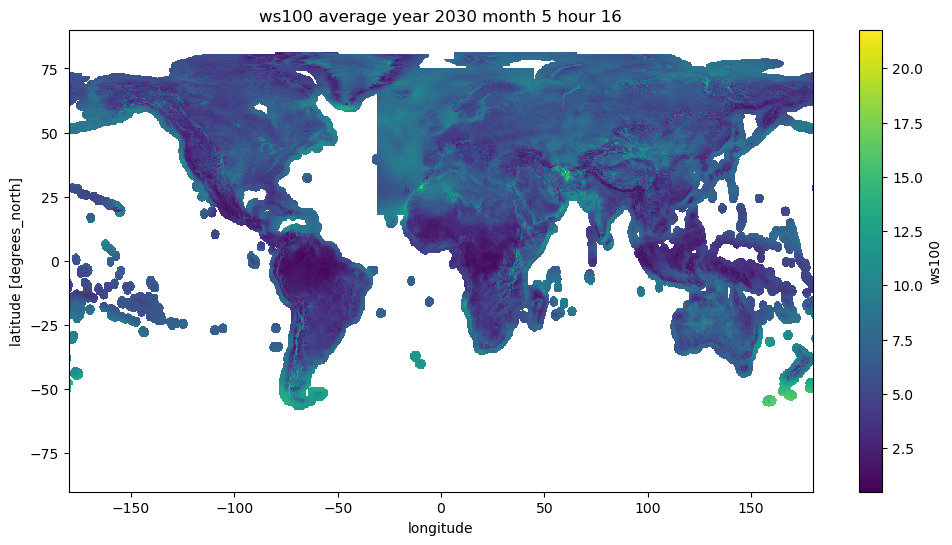

In [19]:
# Compute average of ws100 for month 5 and hour 16
month, hour = 5, 16
plt.figure(figsize=(12, 6))
ds1 = ws100.sel(time=ws100.time.dt.month == 5)
ds1 = ds1.sel(time=ds1.time.dt.hour == 16)
ds1.mean(dim="time").ws100.plot()
title = plt.title(f"ws100 average year {year} month {month} hour {hour}")

In the same way, we will calculate the average wind speed at 84 meters for those values.

Data source: [Pan-European Climate Database (PECD), C3S Climate Data Store](https://cds.climate.copernicus.eu/datasets/sis-energy-pecd)

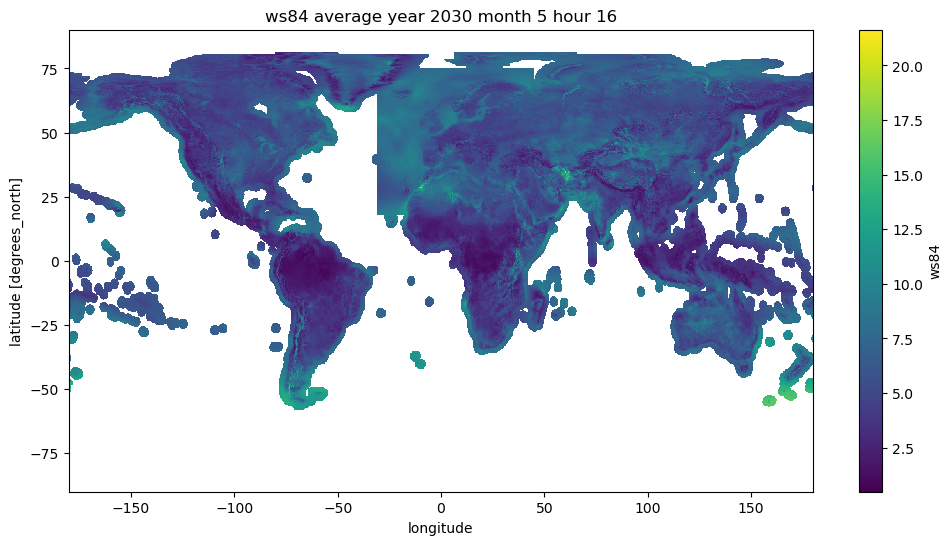

In [20]:
# Compute average of ws100 for month 5 and hour 16
month, hour = 5, 16
plt.figure(figsize=(12, 6))
ds1 = ws84.sel(time=ws84.time.dt.month == 5)
ds1 = ds1.sel(time=ds1.time.dt.hour == 16)
ds1.mean(dim="time").ws84.plot()
title = plt.title(f"ws84 average year {year} month {month} hour {hour}")

Now we are going to plot wind speeds at 10 meters, at 84 meters and at 100 meters to compare them, both for a land location and sea location. We will select a specific month and group values based on hour of the day, then we will take the average of those values:

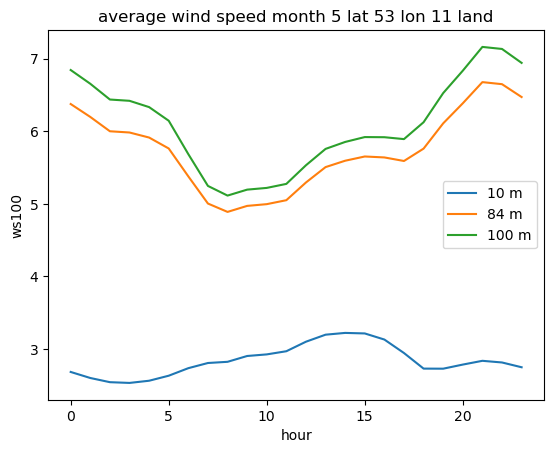

In [21]:
ws10.ws10.sel(time=ws10.time.dt.month == 5).sel(
    latitude=land_lat, longitude=land_lon, method="nearest"
).groupby("time.hour").mean().plot(label="10 m")
ws84.ws84.sel(time=ws84.time.dt.month == 5).sel(
    latitude=land_lat, longitude=land_lon, method="nearest"
).groupby("time.hour").mean().plot(label="84 m")
ws100.ws100.sel(time=ws100.time.dt.month == 5).sel(
    latitude=land_lat, longitude=land_lon, method="nearest"
).groupby("time.hour").mean().plot(label="100 m")
plt.title(f"average wind speed month 5 lat {land_lat} lon {land_lon} land")
plt.legend()

We can see that wind speed at 100 meters is higher than at 10 meters especially at night, when alpha coefficients are higher due to boundary layer stability

Data source: [Pan-European Climate Database (PECD), C3S Climate Data Store](https://cds.climate.copernicus.eu/datasets/sis-energy-pecd)

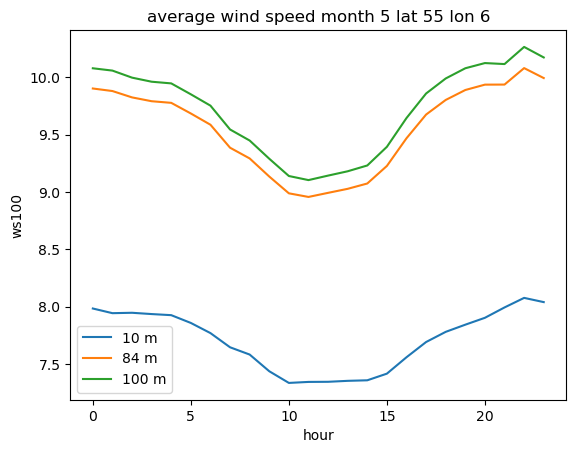

In [22]:
ws10.ws10.sel(time=ws10.time.dt.month == 5).sel(
    latitude=sea_lat, longitude=sea_lon, method="nearest"
).groupby("time.hour").mean().plot(label="10 m")
ws84.ws84.sel(time=ws84.time.dt.month == 5).sel(
    latitude=sea_lat, longitude=sea_lon, method="nearest"
).groupby("time.hour").mean().plot(label="84 m")
ws100.ws100.sel(time=ws100.time.dt.month == 5).sel(
    latitude=sea_lat, longitude=sea_lon, method="nearest"
).groupby("time.hour").mean().plot(label="100 m")
plt.title(f"average wind speed month 5 lat {sea_lat} lon {sea_lon}")
plt.legend()

Now we do the same plot, selecting December and hour 9:00 PM; here there is the plot for ws100

Data source: [Pan-European Climate Database (PECD), C3S Climate Data Store](https://cds.climate.copernicus.eu/datasets/sis-energy-pecd)

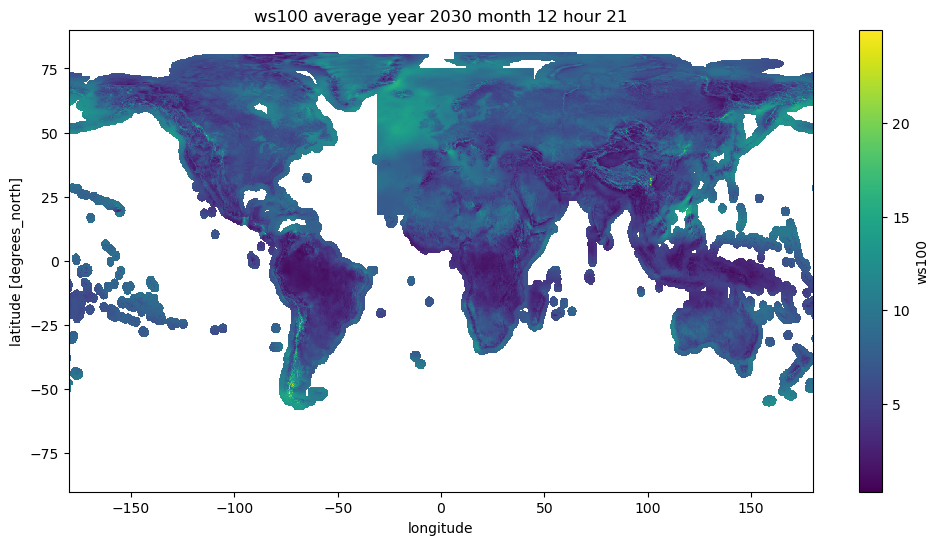

In [24]:
# Compute average of ws100 for month 12 and hour 21
month, hour = 12, 21
plt.figure(figsize=(12, 6))
ds1 = ws100.sel(time=ws100.time.dt.month == 12)
ds1 = ds1.sel(time=ds1.time.dt.hour == 21)
ds1.mean(dim="time").ws100.plot()
title = plt.title(f"ws100 average year {year} month {month} hour {hour}")

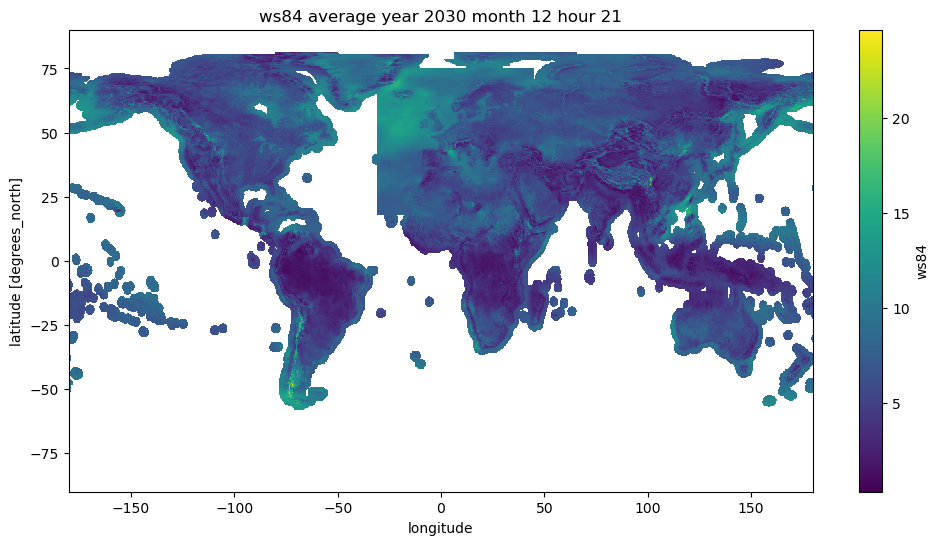

In [25]:
# Compute average of ws100 for month 12 and hour 21
month, hour = 12, 21
ds1 = ws84.sel(time=ws84.time.dt.month == 12)
ds1 = ds1.sel(time=ds1.time.dt.hour == 21)
plt.figure(figsize=(12, 6))
ds1.mean(dim="time").ws84.plot()
title = plt.title(f"ws84 average year {year} month {month} hour {hour}")

## Take home messages 📌

*   Wind shear coefficient can be used to estimate the vertical wind profile and derive wind speed information at different heights above the ground;
*   Alpha coefficients are strongly dependent on the hour of the day, terrain type and season;
*   Using alpha coefficients stratified by hour of the day and month is useful for more realistic wind power modeling;
*   Visualization of average wind speed map for given month and hour of the day using matplotlib